# GCAP3226 Week 3 — Graded in-class exercise (5%)

**Individual** · submit via **your GitHub fork** (end of notebook). Keep answers short.

### What is marked
| Task | Focus |
|------|--------|
| **1** | Stacked bar: one factor **other than** `government_consideration` vs `support_info` + your trend description |
| **2** | Multiple linear regression that builds on the demo, adding `policy_helpfulness` and `waste_severity` + short coefficient interpretation |
| **3** | **Your own** IPO prompt → simple linear regression: `support_info` vs `fairness` |
| **Submit** | Save → Source Control → **Commit & Push** → **commit message** → Commit → Moodle **GitHub URL** |

Use **association** language only. This is a **non-probability** sample — do not claim causation or “all of Hong Kong”.


## How to use AI here (Codespaces)

In the demo you practiced **Input → Process → Output** prompts (**Write Python code** in Process).

**Tasks 1–2:** the prompt is already in the code cell as comments.

**Task 3:** you **write the prompt yourself** in the comments, then use Inline Chat.

Workflow:
1. Click inside the code cell.  
2. Edit / write the comment prompt.  
3. Press **`Cmd+I`** (Mac) or **`Ctrl+I`** (Windows/Linux).  
4. Ask e.g. *Implement the prompt in the comments above* → **Keep**.  
5. Fix anything that breaks; write interpretations **in your own words**.


## Setup (run once)

Load `week3.csv`. Glance at the column names so you know what you can use.


In [1]:
# Setup — run this cell first
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

from sklearn.linear_model import LinearRegression

DATA_FILE = "week3.csv"


def load_week3_data():
    for p in [Path(DATA_FILE), Path.cwd() / DATA_FILE]:
        if p.is_file():
            print("Using data file:", p.resolve())
            return pd.read_csv(p)
    raise FileNotFoundError(
        f"Could not find {DATA_FILE}. Work in your Week 3 fork / Codespace."
    )


df = load_week3_data()
print("shape:", df.shape)
print("columns:", list(df.columns))
df.head()


Using data file: /workspaces/GCAP3226_week3/week3.csv
shape: (97, 12)
columns: ['ID', 'support_info', 'support_after_info', 'government_consideration', 'fairness', 'policy_helpfulness', 'waste_severity', 'recycling_effort', 'age_group', 'monthly_income', 'education', 'education_label']


,ID,support_info,support_after_info,government_consideration,fairness,policy_helpfulness,waste_severity,recycling_effort,age_group,monthly_income,education,education_label
0,1,1,1,1,1,1,3,1,29.5,22500.5,4,Master or above
1,2,5,5,5,5,4,2,2,39.5,7500.0,4,Master or above
2,3,3,5,4,5,2,3,1,29.5,22500.5,4,Master or above
3,4,1,2,1,2,2,3,2,29.5,60000.5,4,Master or above
4,5,1,3,3,4,1,3,2,49.5,22500.5,2,Secondary


## Task 1 — Stacked bar (not the demo pair)

In the demo, the stacked bar used **`government_consideration`** (groups) × **`support_info`** (stack, row %).

**Your job:** choose a **different** grouping variable from `week3.csv` and plot a **row-% stacked bar** of `support_info` within each group.

### Suggested grouping variables (pick one)
| Variable | Notes |
|----------|--------|
| `fairness` | 1–5 |
| `policy_helpfulness` | 1–4 |
| `waste_severity` | 1–4 |
| `recycling_effort` | 1–4 |
| `education` | 1–4 |

Do **not** use `government_consideration` as the grouping variable.

In the **next code cell**, replace `<YOUR_GROUP_VAR>` in the comment prompt with your choice, then use Inline Chat (see **How to use AI** above).


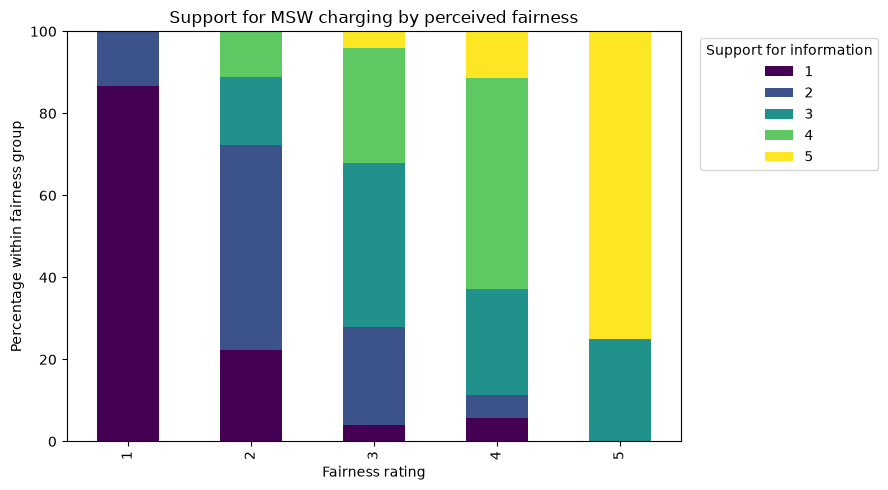

Sample size by fairness group:
fairness
1    15
2    18
3    25
4    35
5     4


In [2]:
# Task 1 — Stacked bar
# --- Sample AI prompt (Input → Process → Output) ---
# Input: dataframe df already loaded from week3.csv.
# Process: Write Python code to make a row-percentage stacked bar chart of
#   support_info within each level of fairness.
#   Drop rows with missing values for these columns. Show n for each group if you can.
#   Add comments to key Python code.
# Output: A stacked bar chart with title, axis labels, and legend.
# --- End prompt ---

# Keep only complete observations for the grouping and response variables.
group_var = "fairness"
plot_data = df[[group_var, "support_info"]].dropna()

# Count support levels within each fairness group and convert rows to percentages.
counts = pd.crosstab(plot_data[group_var], plot_data["support_info"]).sort_index()
row_percent = counts.div(counts.sum(axis=1), axis=0) * 100
sample_sizes = plot_data.groupby(group_var).size()

ax = row_percent.plot(kind="bar", stacked=True, figsize=(9, 5), colormap="viridis")
ax.set_title("Support for MSW charging by perceived fairness")
ax.set_xlabel("Fairness rating")
ax.set_ylabel("Percentage within fairness group")
ax.legend(title="Support for information", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

print("Sample size by fairness group:")
print(sample_sizes.to_string())

### Task 1 — Describe the trend (your words)

In 2–4 sentences: what pattern do you see in **this sample**? Use association language. Mention any thin groups (small *n*) if relevant.

**How to answer:** type inside the `""" ... """` in the next cell, then **run** that cell so your text appears in the output.


In [3]:
# Task 1 — write BETWEEN the triple quotes, then RUN this cell
task1_trend = """
Using fairness as the grouping variable, higher fairness ratings are associated with higher support_info ratings in this sample. For fairness = 1, 86.7% selected support_info = 1, while for fairness = 4, 51.4% selected support_info = 4 and 11.4% selected 5. The fairness = 5 group is thin (n = 4), so its 75.0% at support_info = 5 should be interpreted cautiously; these are associations in this sample, not causal results.
"""
print(task1_trend)


Using fairness as the grouping variable, higher fairness ratings are associated with higher support_info ratings in this sample. For fairness = 1, 86.7% selected support_info = 1, while for fairness = 4, 51.4% selected support_info = 4 and 11.4% selected 5. The fairness = 5 group is thin (n = 4), so its 75.0% at support_info = 5 should be interpreted cautiously; these are associations in this sample, not causal results.



## Task 2 — Multiple linear regression (+ policy & severity)

In the demo you fitted multiple linear regression with `government_consideration` and `fairness` (and a fuller model with demographics).

**Your job:** fit a multiple linear regression for this sample:

**Response:** `support_info`  

**Exploratory variables (at least these four):**
- `government_consideration`
- `fairness`
- `policy_helpfulness`
- `waste_severity`

Use complete cases for these columns. Print **each coefficient**, **R²**, and **n**.  

In the **next code cell**, use the comment prompt with Inline Chat (see **How to use AI** above).


In [4]:
# Task 2 — Multiple linear regression
# --- Sample AI prompt (Input → Process → Output) ---
# Input: dataframe df already loaded from week3.csv.
# Process: Write Python code to run a multiple linear regression with
#   response = support_info and exploratory variables =
#   government_consideration, fairness, policy_helpfulness, waste_severity.
#   Use rows with no missing values on these columns.
#   Print coefficients, R-squared, and n.
#   Add comments to key Python code.
# Output: A clear coefficient table (or printed list), R², and sample size n.
# --- End prompt ---

model_columns = [
    "support_info",
    "government_consideration",
    "fairness",
    "policy_helpfulness",
    "waste_severity",
]
regression_data = df[model_columns].dropna()
X = regression_data[[
    "government_consideration",
    "fairness",
    "policy_helpfulness",
    "waste_severity",
]]
y = regression_data["support_info"]

multiple_model = LinearRegression().fit(X, y)
coefficient_table = pd.Series(multiple_model.coef_, index=X.columns)
print("Intercept:", round(multiple_model.intercept_, 3))
print("Coefficients:")
print(coefficient_table.round(3).to_string())
print("R-squared:", round(multiple_model.score(X, y), 3))
print("n:", len(regression_data))

Intercept: -0.277
Coefficients:
government_consideration    0.483
fairness                    0.379
policy_helpfulness          0.192
waste_severity              0.118
R-squared: 0.639
n: 97


### Task 2 — Report & briefly interpret

1. Paste or list the **coefficients** (and R², n) from your output.  
2. In a few sentences, interpret **two** coefficients that interest you (association; holding the other variables fixed).  
3. One caution (sample / overclaim).

**How to answer:** type inside the `""" ... """` in the next cell, then **run** that cell so your text appears in the output.


In [5]:
# Task 2 — write BETWEEN the triple quotes, then RUN this cell
task2_writeup = """
Coefficients / R² / n:
Intercept = -0.277; government_consideration = 0.483; fairness = 0.379; policy_helpfulness = 0.192; waste_severity = 0.118; R² = 0.639; n = 97.

Interpretation (2 coefficients I care about):
Holding the other three variables fixed, a one-point higher government_consideration score is associated with about 0.483 points higher support_info on average. Holding the other variables fixed, a one-point higher fairness score is associated with about 0.379 points higher support_info on average. These are adjusted associations, not causal effects.

One caution: This is a non-probability sample, so the results may not represent all Hong Kong residents. The regression also shows association rather than causation.
"""
print(task2_writeup)


Coefficients / R² / n:
Intercept = -0.277; government_consideration = 0.483; fairness = 0.379; policy_helpfulness = 0.192; waste_severity = 0.118; R² = 0.639; n = 97.

Interpretation (2 coefficients I care about):
Holding the other three variables fixed, a one-point higher government_consideration score is associated with about 0.483 points higher support_info on average. Holding the other variables fixed, a one-point higher fairness score is associated with about 0.379 points higher support_info on average. These are adjusted associations, not causal effects.

One caution: This is a non-probability sample, so the results may not represent all Hong Kong residents. The regression also shows association rather than causation.



## Task 3 — Write your own prompt (simple linear regression)

**Goal:** `support_info` (response) vs `fairness` (one exploratory variable) — a **simple** linear regression on this sample.

Unlike Tasks 1–2, **do not** copy a ready-made Process. In the **next code cell**, write the full **Input / Process / Output** in the comments (**Process** must include **Write Python code**), then use Inline Chat (see **How to use AI** above).

Keep the model to **these two variables only** (not the Task 2 multiple linear regression). You should get coefficients, R², and n.


In [6]:
# Task 3 — YOUR prompt
# --- Write your AI prompt here (Input → Process → Output) ---
# Input: Use the dataframe df loaded from week3.csv. The response variable is
# support_info and the single exploratory variable is fairness.
# Process: Write Python code to drop rows missing either variable, fit a simple
# linear regression with support_info as y and fairness as X, and print the
# intercept, fairness coefficient, R-squared, and sample size n. Use only these
# two variables and add short comments explaining the key steps.
# Output: Print a clear result showing the intercept, fairness slope, R-squared,
# and n, so the fairness association can be interpreted.
# --- End prompt ---
# Requirement: simple linear regression only — response = support_info, exploratory = fairness.

simple_data = df[["support_info", "fairness"]].dropna()
simple_model = LinearRegression().fit(simple_data[["fairness"]], simple_data["support_info"])
print("Intercept:", round(simple_model.intercept_, 3))
print("Fairness slope:", round(simple_model.coef_[0], 3))
print("R-squared:", round(simple_model.score(simple_data[["fairness"]], simple_data["support_info"]), 3))
print("n:", len(simple_data))

Intercept: 0.495
Fairness slope: 0.794
R-squared: 0.522
n: 97


### Task 3 — Short note

In 1–2 sentences: what does the **fairness** slope mean in this simple linear regression? How does it compare (roughly) with the fairness coefficient in your **Task 2** multiple linear regression?

**How to answer:** type inside the `""" ... """` in the next cell, then **run** that cell.


In [7]:
# Task 3 — write BETWEEN the triple quotes, then RUN this cell
task3_note = """
The fairness slope is 0.794, so a one-point increase in fairness is associated with about 0.794 points higher support_info on average in the simple model. The Task 2 fairness coefficient is smaller, 0.379, after adjusting for government_consideration, policy_helpfulness, and waste_severity; both describe associations, not causal effects.
"""
print(task3_note)


The fairness slope is 0.794, so a one-point increase in fairness is associated with about 0.794 points higher support_info on average in the simple model. The Task 2 fairness coefficient is smaller, 0.379, after adjusting for government_consideration, policy_helpfulness, and waste_severity; both describe associations, not causal effects.



## How to submit

Submit the **GitHub URL** of this notebook in **your fork** (not an `.ipynb` upload).

1. **Save** the notebook.  
2. Open **Source Control** (left sidebar, branch icon).  
3. Click **Commit & Push**.  
4. Type a **commit message** → click **Commit**.  
5. On github.com, open the file in **your fork** → copy the browser URL.  
6. Paste that URL on **Moodle**.

**If push fails:** ask a TA — keep working toward a push to your fork.

### Checklist
- [ ] Task 1: stacked bar (not `government_consideration` groups) + trend description  
- [ ] Task 2: multiple linear regression with the four required variables + coefficient write-up  
- [ ] Task 3: **your own** IPO prompt + simple linear regression (`support_info` vs `fairness`)  
- [ ] Saved → Commit & Push → commit message → Commit  
- [ ] Moodle: GitHub link submitted  
